In [ ]:
!pip install pandas scikit-learn matplotlib seaborn

In [1]:
!pip install pyspellchecker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 34.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from spellchecker import SpellChecker
from nltk.sentiment.vader import SentimentIntensityAnalyzer as SIA


In [3]:
df = pd.read_csv('/content/elon_musk_tweets.csv')


In [4]:
df = df.drop('hashtags', axis=1)

In [5]:
data = df.copy()

#EDA

In [6]:
from datetime import datetime
import dateutil.parser

data['original_tweet'] = data['text']
data['datetime'] = data['date']
data['datetime'] = data.datetime.apply(lambda x: dateutil.parser.parse(x))
rt_mask = data.text.apply(lambda x:"RT @" in x)

data.text = data.text.str.lower()
#Remove twitter handlers
data.text = data.text.apply(lambda x:re.sub('@[^\s]+','',x))
#remove hashtags
data.text = data.text.apply(lambda x:re.sub(r'\B#\S+','',x))
# Remove URLS
data.text = data.text.apply(lambda x:re.sub(r"http\S+", "", x))
# Remove all the special characters
data.text = data.text.apply(lambda x:' '.join(re.findall(r'\w+', x)))
#remove all single characters
data.text = data.text.apply(lambda x:re.sub(r'\s+[a-zA-Z]\s+', '', x))
# Substituting multiple spaces with single space
data.text = data.text.apply(lambda x:re.sub(r'\s+', ' ', x, flags=re.I))

In [7]:
# convert the 'date' column to datetime format and remove the timezone information
data['datetime'] = pd.to_datetime(data['datetime']).dt.tz_localize(None)


# Viewing the preprocessed data
data.head()

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,source,retweets,favorites,is_retweet,original_tweet,datetime
0,1544379368478212100,Elon Musk,NaN,"Mars & Cars, Chips & Dips",2009-06-02 20:12:29+00:00,101240855,115,13503,True,2022-07-05 17:55:09+00:00,i find the gold toe sock inevitably off kilter...,Twitter for iPhone,335,6542,False,@BillyM2k I find the gold toe sock – inevitabl...,2022-07-05 17:55:09
1,1544377493263720450,Elon Musk,NaN,"Mars & Cars, Chips & Dips",2009-06-02 20:12:29+00:00,101240806,115,13503,True,2022-07-05 17:47:42+00:00,sock con the conference for socks,Twitter for iPhone,1451,30753,False,"Sock Con, the conference for socks",2022-07-05 17:47:42
2,1544377130590552064,Elon Musk,NaN,"Mars & Cars, Chips & Dips",2009-06-02 20:12:29+00:00,101240806,115,13503,True,2022-07-05 17:46:15+00:00,always something new for the magazine cover an...,Twitter for iPhone,1284,28610,False,Always something new for the magazine cover an...,2022-07-05 17:46:15
3,1544375575724400645,Elon Musk,NaN,"Mars & Cars, Chips & Dips",2009-06-02 20:12:29+00:00,101240806,115,13503,True,2022-07-05 17:40:05+00:00,this guy gets it,Twitter for iPhone,131,3640,False,@ExplainThisBob This guy gets it,2022-07-05 17:40:05
4,1544375148605853699,Elon Musk,NaN,"Mars & Cars, Chips & Dips",2009-06-02 20:12:29+00:00,101240806,115,13503,True,2022-07-05 17:38:23+00:00,sock tech is so advanced that you can get pret...,Twitter for iPhone,1191,23790,False,Sock tech is so advanced that you can get pret...,2022-07-05 17:38:23


In [8]:
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from spellchecker import SpellChecker
from nltk.sentiment.vader import SentimentIntensityAnalyzer as SIA
from tqdm import tqdm # Make sure to import tqdm


# Download the VADER lexicon
nltk.download('vader_lexicon')

def label_sentiment(x:float):
  if x < 0: return 'Negative'
  elif x > 0: return 'Positive'
  else: return 'Neutral'

spell = SpellChecker()
sia = SIA()

# Feature Extraction
data['words'] = data.text.apply(lambda x:re.findall(r'\w+', x ))
data['errors'] = data.words.apply(spell.unknown)
data['errors_count'] = data.errors.apply(len)
data['words_count'] = data.words.apply(len)
data['sentence_length'] = data.text.apply(len)
data['hour'] = data.datetime.apply(lambda x: x.hour)
data['date'] = data.datetime.apply(lambda x: x.date())
data['month'] = data.datetime.apply(lambda x: x.month)
data['year'] = data.datetime.apply(lambda x: x.year)


# Extract Sentiment Values for each tweet
data['sentiment'] = [sia.polarity_scores(x)['compound'] for x in tqdm(data['text'])]
data['overall_sentiment'] = data['sentiment'].apply(label_sentiment);



[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
100%|██████████| 5904/5904 [00:01<00:00, 3177.04it/s]


In [9]:
!pip install plotly
import plotly.express as px

# Count non-null values per feature
non_null_counts = data.notnull().sum()

# Create a bar plot using Plotly Express
fig = px.bar(
    x=non_null_counts.index,
    y=non_null_counts.values,
    labels={'x': 'Features', 'y': 'Non-Null Count'},
    title='Non-Null Values per Feature'
)

# Update layout for better readability
fig.update_layout(
    xaxis_tickangle=-45,  # Rotate x-axis labels
    xaxis_title='Features',
    yaxis_title='Non-Null Count',
    title_x=0.5  # Center the title
)

fig.show()

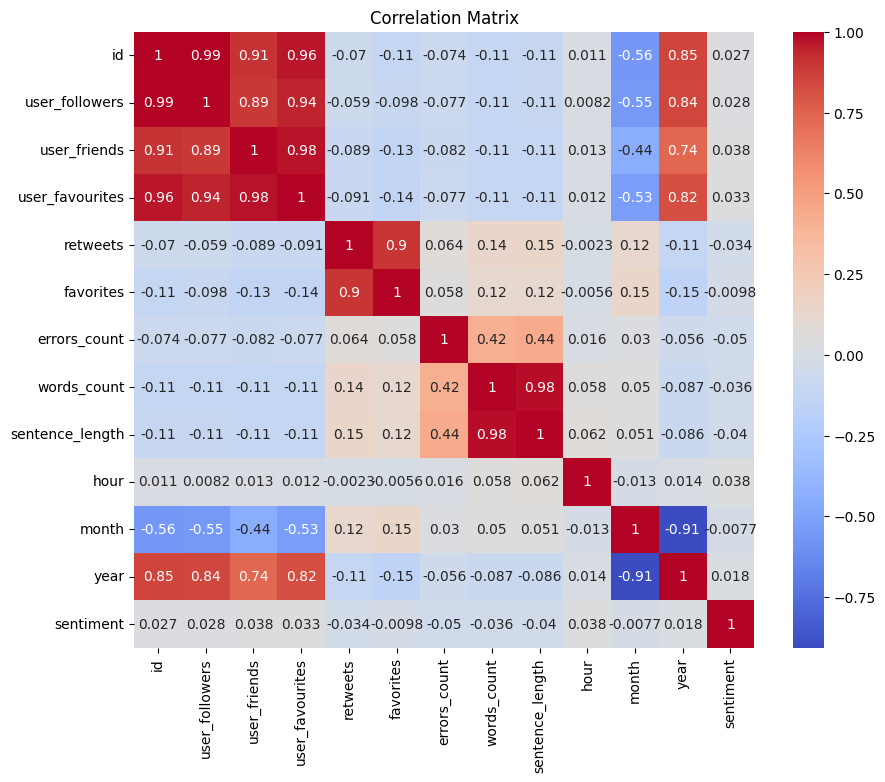

In [10]:
numeric_data = data.select_dtypes(include=['number'])
corr_matrix = numeric_data.corr()
f, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', ax = ax)
plt.title('Correlation Matrix')
plt.show()

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5904 entries, 0 to 5903
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 5904 non-null   int64         
 1   user_name          5904 non-null   object        
 2   user_location      1050 non-null   object        
 3   user_description   1422 non-null   object        
 4   user_created       5904 non-null   object        
 5   user_followers     5904 non-null   int64         
 6   user_friends       5904 non-null   int64         
 7   user_favourites    5904 non-null   int64         
 8   user_verified      5904 non-null   bool          
 9   date               5904 non-null   object        
 10  text               5904 non-null   object        
 11  source             5904 non-null   object        
 12  retweets           5904 non-null   int64         
 13  favorites          5904 non-null   int64         
 14  is_retwe

<ipython-input-12-30b5fa99dd9a>:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




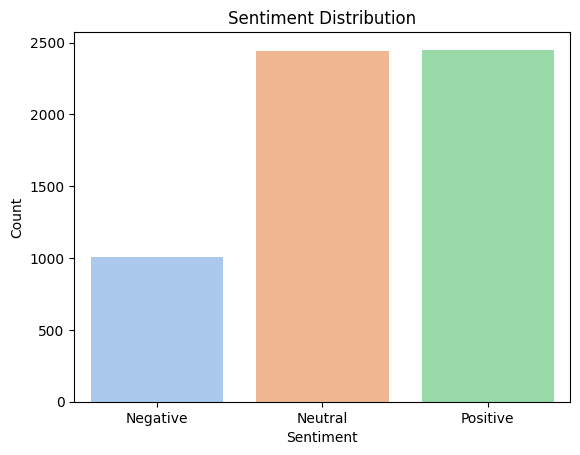

In [12]:
sns.countplot(x='overall_sentiment', data=data, palette= 'pastel')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

#Cleaning Data and Tokenizing

In [13]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Assuming the dataframe is named `df`
# Drop specified columns
columns_to_drop = [
    "user_name", "user_location", "user_description",
    "user_created", "user_verified", "date",
    "source", "sentiment", "original_tweet", "is_retweet", "words", "errors", "datetime"
]
df_cleaned = data.drop(columns=columns_to_drop)

# Vectorize 'words', 'errors', and 'text' columns
vectorizer = TfidfVectorizer()
text_vectorized = vectorizer.fit_transform(df_cleaned["text"])

# Encode 'overall_sentiment'
label_encoder = LabelEncoder()
overall_sentiment_encoded = label_encoder.fit_transform(df_cleaned["overall_sentiment"])

# Combine all processed features into a single DataFrame for further use
processed_df = pd.concat(
    [
        pd.DataFrame(text_vectorized.toarray(), columns=vectorizer.get_feature_names_out(), index=df_cleaned.index),
        df_cleaned.drop(columns=["text", "overall_sentiment"]).reset_index(drop=True)
    ],
    axis=1
)

# Add encoded sentiment as a separate column
processed_df["overall_sentiment"] = overall_sentiment_encoded

# Display the shape and head of the processed DataFrame
processed_df.shape, processed_df.head()


((5904, 8082),
    000   10  100  1000  1000s  1000x  100b  100k  100m  100x  ...  \
 0  0.0  0.0  0.0   0.0    0.0    0.0   0.0   0.0   0.0   0.0  ...   
 1  0.0  0.0  0.0   0.0    0.0    0.0   0.0   0.0   0.0   0.0  ...   
 2  0.0  0.0  0.0   0.0    0.0    0.0   0.0   0.0   0.0   0.0  ...   
 3  0.0  0.0  0.0   0.0    0.0    0.0   0.0   0.0   0.0   0.0  ...   
 4  0.0  0.0  0.0   0.0    0.0    0.0   0.0   0.0   0.0   0.0  ...   
 
    user_favourites  retweets  favorites  errors_count  words_count  \
 0            13503       335       6542             4           17   
 1            13503      1451      30753             0            6   
 2            13503      1284      28610             0           13   
 3            13503       131       3640             0            4   
 4            13503      1191      23790             1           17   
 
    sentence_length  hour  month  year  overall_sentiment  
 0              112    17      7  2022                  0  
 1             

In [14]:
processed_df.head()

,000,10,100,1000,1000s,1000x,100b,100k,100m,100x,...,user_favourites,retweets,favorites,errors_count,words_count,sentence_length,hour,month,year,overall_sentiment
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,13503,335,6542,4,17,112,17,7,2022,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,13503,1451,30753,0,6,33,17,7,2022,1
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,13503,1284,28610,0,13,89,17,7,2022,1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,13503,131,3640,0,4,16,17,7,2022,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,13503,1191,23790,1,17,86,17,7,2022,2


In [15]:
processed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5904 entries, 0 to 5903
Columns: 8082 entries, 000 to overall_sentiment
dtypes: float64(8069), int64(13)
memory usage: 364.0 MB


#Model Training

Sklearn Logistic Regression

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(processed_df.drop(columns=["overall_sentiment"]), processed_df["overall_sentiment"], test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))

Accuracy: 0.3937341236240474
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       203
           1       0.00      0.00      0.00       513
           2       0.39      1.00      0.57       465

    accuracy                           0.39      1181
   macro avg       0.13      0.33      0.19      1181
weighted avg       0.16      0.39      0.22      1181



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



Custom Logistic Regression

In [17]:
def softmax(z):
  exp_z = np.exp(z - np.max(z, axis=1,keepdims=True))
  return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [18]:
def cost(X, y, weights, lambda_):
  m = len(y)
  predictions = softmax(np.dot(X, weights))
  cost = -1/m * np.sum(np.log(predictions[range(m), y]))
  regularization = lambda_/(2*m) * np.sum(weights**2)
  return cost + regularization



In [19]:
def gradient_descent(X, y, weights, learning_rate, num_iterations, lambda_):
    m = len(y)  # Number of examples
    for i in range(num_iterations):
        # Compute predictions (softmax probabilities)
        predictions = softmax(np.dot(X, weights))

        # Compute the gradient for each weight
        # For multiclass classification, the gradient is based on the difference between the predicted probabilities
        # and the actual classes (i.e., y)
        gradient = (1 / m) * np.dot(X.T, (predictions - np.eye(3)[y]))  # 3 is number of classes

        # Add L2 regularization term (except for the bias term, i.e., weights[0])
        gradient[1:] += (lambda_ / m) * weights[1:]

        # Update the weights using the gradient
        weights -= learning_rate * gradient

        # Optionally, print cost every 100 iterations to monitor convergence
        if i % 100 == 0:
            # Call the cost function and assign its result to a variable (e.g., current_cost)
            current_cost = cost(X, y, weights, lambda_)
            print(f"Iteration {i}: Cost = {current_cost}")

    return weights

In [20]:
# Custom Logistic Regression for Multiclass with Regularization
class CustomMulticlassLogisticRegression:
    def __init__(self, learning_rate=0.01, iterations=1000, lambda_=0.1):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.lambda_ = lambda_
        self.weights = None

    def fit(self, X, y, num_classes):
        # Add intercept column with 1s to the feature matrix
        X = np.hstack((np.ones((X.shape[0], 1)), X))
        # Initialize weights (one weight vector per class)
        self.weights = np.zeros((X.shape[1], num_classes))

        # Perform gradient descent to fit the model
        self.weights = gradient_descent(X, y, self.weights, self.learning_rate, self.iterations, self.lambda_)

    def predict(self, X):
        # Add intercept column with 1s to the feature matrix
        X = np.hstack((np.ones((X.shape[0], 1)), X))
        # Predict probabilities for each class using softmax
        predictions = softmax(np.dot(X, self.weights))
        # Return class labels (0, 1, 2 for 3 classes)
        return np.argmax(predictions, axis=1)

    def score(self, X, y):
        # Calculate accuracy by comparing predictions to true labels
        y_pred = self.predict(X)
        accuracy = np.mean(y_pred == y)
        return accuracy


In [21]:
# Assume processed_df_tfidf is ready, and `overall_sentiment` is 0 for Negative, 1 for Neutral, 2 for Positive

# Prepare features (X) and labels (y)
X = processed_df.drop(columns=["overall_sentiment"]).values
y = processed_df["overall_sentiment"].values

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the custom multiclass logistic regression model
num_classes = len(np.unique(y))
custom_lr_model = CustomMulticlassLogisticRegression(learning_rate=0.01, iterations=1000, lambda_=0.1)

# Train the model
custom_lr_model.fit(X_train, y_train, num_classes)

# Evaluate the model
accuracy = custom_lr_model.score(X_test, y_test)
print(f"Custom Multiclass Logistic Regression Model Accuracy: {accuracy:.4f}")


<ipython-input-18-8203d67072af>:4: RuntimeWarning:

divide by zero encountered in log



Iteration 0: Cost = inf
Iteration 100: Cost = inf
Iteration 200: Cost = inf
Iteration 300: Cost = inf
Iteration 400: Cost = inf
Iteration 500: Cost = inf


KeyboardInterrupt: 

XGBoost   

In [22]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(processed_df.drop(columns=["overall_sentiment"]), processed_df["overall_sentiment"], test_size=0.2, random_state=42)

X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

xgboost_model = xgb.XGBClassifier(objective='multi:softmax', num_class=3, random_state=42)
xgboost_model.fit(X_train, y_train)
y_pred = xgboost_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))

Accuracy: 0.781541066892464
              precision    recall  f1-score   support

           0       0.79      0.37      0.50       203
           1       0.73      0.95      0.82       513
           2       0.86      0.78      0.82       465

    accuracy                           0.78      1181
   macro avg       0.79      0.70      0.72      1181
weighted avg       0.79      0.78      0.77      1181



Random Forests

In [23]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Calculate accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")


Random Forest Accuracy: 0.7019


RNN LSTM

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class LSTMModel(nn.Module):
    def __init__(self, input_size, embedding_dim, hidden_size, num_layers, output_dim, dropout_prob):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(input_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers, batch_first=True, dropout=dropout_prob)
        self.dropout = nn.Dropout(dropout_prob)
        self.fc1 = nn.Linear(hidden_size, 64)
        self.fc2 = nn.Linear(64, output_dim)
        self.softmax = nn.Softmax(dim=1)
        self.relu = nn.ReLU() # Added ReLU activation

    def forward(self, x):
        # Clip input indices to be within the vocabulary size
        x = torch.clamp(x, 0, self.embedding.num_embeddings - 1)
        x = self.embedding(x)
        x, (hn, cn) = self.lstm(x)
        x = self.dropout(hn[-1])
        x = self.fc1(x)
        x = self.relu(x)  # Apply ReLU activation here
        x = self.fc2(x)
        x = self.softmax(x)
        return x

embedding_dim =128
hidden_dim = 128
output_dim = len(set(y_train))
dropout_prob = 0.3
learning_rate = 0.001
epochs = 5
batch_size = 32


X_train_tensor = torch.tensor(X_train, dtype=torch.long).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.long).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model = LSTMModel(input_size=len(vectorizer.vocabulary_), embedding_dim=embedding_dim, hidden_size=hidden_dim, num_layers=2, output_dim=output_dim, dropout_prob=dropout_prob).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
  model.train()
  running_loss = 0.0
  correct_preds = 0
  total_preds  = 0

  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()

    _, predicted = torch.max(outputs.data, 1)
    total_preds += labels.size(0)
    correct_preds += (predicted == labels).sum().item()

  epoch_loss = running_loss / len(train_loader)
  epoch_accuracy = correct_preds / total_preds

  print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")

model.eval()
correct_preds = 0
total_preds = 0

with torch.no_grad():
  for inputs, labels in test_loader:
    outputs = model(inputs)
    _, predicted = torch.max(outputs.data, 1)
    total_preds += labels.size(0)
    correct_preds += (predicted == labels).sum().item()

test_accuracy = correct_preds / total_preds
print(f"Test Accuracy: {test_accuracy:.4f}")

Epoch [1/5], Loss: 1.0516, Accuracy: 0.4105
Epoch [2/5], Loss: 1.0389, Accuracy: 0.4410
Epoch [3/5], Loss: 1.0114, Accuracy: 0.5206
Epoch [4/5], Loss: 0.9943, Accuracy: 0.5386
Epoch [5/5], Loss: 0.9702, Accuracy: 0.5666
Test Accuracy: 0.5318
